In [1]:
import kagglehub
import numpy as np
import pandas as pd
import duckdb
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import norm

c:\Users\ASUS\Documents\DS Projects\Kaggle Landing Page AB Testing\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#get data from kaggle
path = kagglehub.dataset_download("zhangluyuan/ab-testing")
df = pd.read_csv(Path(path) / "ab_data.csv")

df.head()


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
#find out if type conversions are necessary
#look at initial memory usage
df.info(memory_usage = "deep")

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 57.6 MB


In [4]:
#find out if downcasting integers is viable
df.describe() 

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


DATA CLEANING:

#Casting: 

- 'user_id' column can be downcast to an int32
- 'timestamp' column needs to be converted to an actual timestamp
- 'group' and 'landing_page' columns can be converted to categories
- 'converted' column could be converted to a boolean

#Further info obtained from data wrangler:

- no null or erroneous values in any column
- many repeated user_id's (~1%) - find out if it's okay to keep them

In [5]:
df['user_id'] = df['user_id'].astype('int32')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['group'] = df['group'].astype('category')
df['landing_page'] = df['landing_page'].astype('category')
df['converted'] = df['converted'].astype('bool')

df.info(memory_usage='deep') #memory reduced from 57.6MB to 4.2MB

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       294478 non-null  int32         
 1   timestamp     294478 non-null  datetime64[us]
 2   group         294478 non-null  category      
 3   landing_page  294478 non-null  category      
 4   converted     294478 non-null  bool          
dtypes: bool(1), category(2), datetime64[us](1), int32(1)
memory usage: 4.2 MB


In [6]:
dupl = duckdb.sql(
"""
--Remove rows where the the landing page does not correspond to the correct group

WITH valid_group AS(
SELECT * FROM df WHERE ("group" = 'treatment' AND landing_page = 'new_page') OR ("group" = 'control' AND landing_page = 'old_page')
)

--Any remaining duplicate rows will have the same group and landing page, so just keep the one with the earlier timestamp

SELECT * EXCLUDE(rn) FROM(SELECT *, ROW_NUMBER() OVER(partition by user_id ORDER BY timestamp) AS rn FROM valid_group) WHERE rn = 1
"""
).df()

dupl

,user_id,timestamp,group,landing_page,converted
0,796352,2017-01-05 17:58:51.064672,treatment,new_page,False
1,848169,2017-01-21 02:01:23.157766,control,old_page,False
2,820484,2017-01-16 10:14:14.586476,control,old_page,False
3,717975,2017-01-15 08:18:16.750058,control,old_page,False
4,686308,2017-01-14 23:53:31.261222,treatment,new_page,False
...,...,...,...,...,...
290579,679201,2017-01-07 15:28:54.854990,control,old_page,False
290580,643555,2017-01-13 23:20:27.474332,control,old_page,False
290581,655717,2017-01-07 20:42:50.811904,treatment,new_page,False
290582,785309,2017-01-07 13:40:29.858978,control,old_page,False


In [7]:
control = df[(df["group"] == "control")]
treatment = df[(df["group"] == "treatment")]

control_conversions = control["converted"].sum()
treatment_conversions = treatment["converted"].sum()

control_conversion_rate = control_conversions / len(control)
treatment_conversion_rate = treatment_conversions / len(treatment)

print(control_conversion_rate)
print(treatment_conversion_rate)

0.12039917935897611
0.11891957956489856


In [8]:
#create dictionary for results and convert to dataframe

stats = pd.DataFrame({
    "Group" : ["Control", "Treatment"],
    "No. Users" : [len(control), len(treatment)],
    "No. Conversions" : [control_conversions, treatment_conversions],
    "Conversion Rate" : [control_conversion_rate, treatment_conversion_rate]
})

stats


,Group,No. Users,No. Conversions,Conversion Rate
0,Control,147202,17723,0.120399
1,Treatment,147276,17514,0.118920


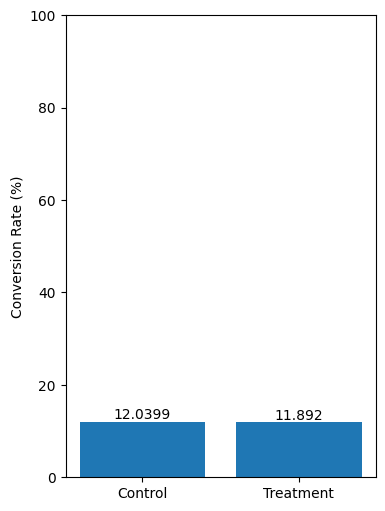

In [9]:
#demosntrate conversion rates in a bar chart

plt.figure(figsize=(4,6))
bar_chart = plt.bar(
    x = ["Control", "Treatment"],
    height = [control_conversion_rate * 100, treatment_conversion_rate * 100] 
)
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, 100)
plt.bar_label(bar_chart)
plt.show()


# A/B Test: Two-Proportion Z-Test

## Problem

Let

- $p_C$ = true conversion proportion in the control group
- $p_T$ = true conversion proportion in the treatment group

We wish to determine whether the treatment group has a higher conversion rate than the control group.

### Hypotheses

$$
H_0 : p_T = p_C
$$

equivalently,

$$
H_0 : p_T - p_C = 0
$$

versus

$$
H_1 : p_T > p_C
$$

equivalently,

$$
H_1 : p_T - p_C > 0
$$

We choose a significance level of

$$
\alpha = 0.05.
$$

In [10]:
#re-assign variables to be used in a mathematical context

n_t = len(treatment)
x_t = treatment_conversions

n_c = len(control)
x_c = control_conversions

p_hat_t = treatment_conversion_rate
p_hat_c = control_conversion_rate

#re-affirm output
print(f"Treatment conversion rate = {p_hat_t:.6f}")
print(f"Control conversion rate   = {p_hat_c:.6f}")
print(f"Difference                = {p_hat_t - p_hat_c:.6f}")

Treatment conversion rate = 0.118920
Control conversion rate   = 0.120399
Difference                = -0.001480


## Estimators

The population proportions $p_T$ and $p_C$ are unknown.

We estimate them using the sample proportions

$$
\hat p_T = \frac{x_T}{n_T}
$$

and

$$
\hat p_C = \frac{x_C}{n_C}.
$$

These estimators are unbiased because

$$
E[\hat p_T] = p_T
$$

and

$$
E[\hat p_C] = p_C.
$$

Therefore the estimator

$$
\hat p_T - \hat p_C
$$

is also unbiased for

$$
p_T - p_C.
$$

## Test Construction

To perform the hypothesis test, assume the null hypothesis is true.

Under

$$
H_0 : p_T = p_C = p,
$$

both groups share a common population proportion $p$.

Since $p$ is unknown, we estimate it using the pooled proportion

$$
\hat p
=
\frac{x_T+x_C}{n_T+n_C}.
$$

In [11]:
p_pool = (x_t + x_c) / (n_t + n_c)

print(f"Pooled proportion = {p_pool:.9f}")

Pooled proportion = 0.119659194


For these data,

$$
\hat p
=
\frac{17723+17514}
{147202+147276}
=
0.119659.
$$

## Standard Error

Under the null hypothesis, the sampling distribution of

$$
\hat p_T-\hat p_C
$$

has variance

$$
\operatorname{Var}(\hat p_T-\hat p_C)
=
p(1-p)
\left(
\frac1{n_T}
+
\frac1{n_C}
\right).
$$

Replacing $p$ with the pooled estimate gives the estimated standard error

$$
SE
=
\sqrt{
\hat p(1-\hat p)
\left(
\frac1{n_T}
+
\frac1{n_C}
\right)
}.
$$

In [12]:
se_pooled = np.sqrt(
    p_pool*(1-p_pool)*(1/n_t + 1/n_c)
)

print(f"SE = {se_pooled:.6f}")

SE = 0.001196


This standard error measures the typical variation of

$$
\hat p_T-\hat p_C
$$

that we would expect if the null hypothesis were true.

## Standardising the Difference

The observed difference between the sample proportions is

$$
\hat p_T-\hat p_C.
$$

To determine whether this difference is unusually large, we standardise it:

$$
Z
=
\frac{
(\hat p_T-\hat p_C)- (p_T - p_C)
}
{
SE
}.
$$

The numerator measures how far the observed difference is from the value predicted by the null hypothesis.

The denominator measures the typical size of random sampling fluctuations.

Under the null hypothesis,

$$
Z \sim N(0,1).
$$

In [13]:
z = (p_hat_t - p_hat_c) / se_pooled

print(f"test statistic is {z:.6f}")

test statistic is -1.236922


Recall the conversion proprtions:

$$
\hat p_T
=
\frac{17514}{147276}
\approx 0.118923,
$$

and

$$
\hat p_C
=
\frac{17723}{147202}
\approx 0.120404.
$$

Therefore

$$
\hat p_T-\hat p_C
=
0.118923-0.120404
=
-0.001481.
$$

Using the pooled standard error

$$
SE
=
0.001196,
$$

the test statistic is

$$
Z
=
\frac{(\hat p_T-\hat p_C)-(p_T - p_C)}{SE}
=
\frac{(-0.001481)-(0)}{0.001196}
=
-1.237.
$$

The critical value of this right-tailed test is:

$$
P(Z > z_{0.95}) = 0.05.
$$

From the standard normal distribution,

$$
z_{0.95}=1.64485.
$$

In [14]:
critical = norm.ppf(0.95)

print(f"critical value = {critical:.6f}")

critical value = 1.644854


Since

$$
-1.237 < 1.645,
$$

the test statistic does not lie in the rejection region.

Therefore we fail to reject the null hypothesis.

## Conclusion

There is insufficient evidence at the 5% significance level to conclude that the treatment page has a higher conversion rate than the control page.

The observed difference is small enough that it could reasonably be explained by random sampling variation.

## P-value

The p-value is the probability, assuming the null hypothesis is true, of observing a test statistic at least as extreme as the one obtained.

For a right-tailed test,

$$
p\text{-value}
=
P(Z \ge z).
$$

In [15]:
p_value = 1 - norm.cdf(z)

print(f"P-value = {p_value:.6f}")

P-value = 0.891942


For this data,

$$
p\text{ value}
\approx 0.892.
$$

Because

$$
0.892 > 0.05,
$$

We fail to reject the null hypothesis once again

# Confidence Interval for $p_T-p_C$

A confidence interval estimates the size of the treatment effect.

Unlike the hypothesis test, we do not assume

$$
p_T=p_C.
$$

Therefore we use the unpooled standard error

$$
SE
=
\sqrt{
\frac{\hat p_T(1-\hat p_T)}{n_T}
+
\frac{\hat p_C(1-\hat p_C)}{n_C}
}.
$$

In [16]:
se_unpooled = np.sqrt(
    p_hat_t*(1-p_hat_t)/n_t +
    p_hat_c*(1-p_hat_c)/n_c
)

print(f"Unpooled SE = {se_unpooled:.9f}")

Unpooled SE = 0.001196194


For a 95% confidence interval,

$$
z^* = 1.959964.  \text{ (The critical value from the stanard normal)}
$$

The confidence interval is

$$
(\hat p_T-\hat p_C)
\pm
z^*SE.
$$

In [18]:
z_star = norm.ppf(0.975)

difference = p_hat_t - p_hat_c

lower = difference - z_star*se_unpooled
upper = difference + z_star*se_unpooled

print(f"95% CI = ({lower:.6f}, {upper:.6f})")

95% CI = (-0.003824, 0.000865)


For these data the 95% confidence interval is approximately

$$
(-0.00382,\;0.00086).
$$

Expressed as percentages,

$$
(-0.382\%,\;0.086\%).
$$

## Interpretation of the Confidence Interval

The interval contains zero.

Therefore the data is consistent with:

- the treatment page performing slightly worse,
- no real difference between the pages,
- the treatment page performing slightly better.

Because zero lies inside the interval, the confidence interval agrees with the hypothesis test conclusion.

There is insufficient evidence that the treatment page improves conversion.